# Reproduce Figures – Ketkar & Sporar 2020

This notebook loads calcium imaging data from `.mat` files, processes them through the ported MATLAB pipeline, saves aligned trace + stimulus data to HDF5, and plots the results for visual verification against the published figures.

**Figures covered:**
- Figure 2B: 5s full-field flash (L2, L3)
- Figure 2C: 60s full-field flash (L3)
- Figure 2D-E: Contrast steps from grey baseline (L2, L3)
- Figure 3A: Adapting contrast steps (L2, L3)
- Figure 3F: Random luminance steps between 5 levels (L2, L3)

**Requirements:** scipy, numpy, h5py, matplotlib, pandas, openpyxl

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path

import utils

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA_ROOT = Path("data/in vivo two-photon calcium imaging")
HDF5_PATH = Path("processed_data.h5")
summary = utils.load_summary()

In [2]:
def plot_err_patch(ax, t, mean, sem, color, label=None):
    """Plot mean trace with shaded SEM, matching the paper style."""
    ax.fill_between(t, mean - sem, mean + sem, color=color, alpha=0.25)
    line, = ax.plot(t, mean, color=color, linewidth=1.5, label=label)
    return line

def process_and_save(h5f, group_name, rats, fly_ids, time_axis, stimulus,
                     cell_type, stimulus_type, roi_names=None,
                     epoch_labels=None, extra_attrs=None):
    """Run mean_cat_full and save everything to HDF5."""
    # Clean: remove all-zero / all-NaN ROIs
    if rats.ndim == 2:
        valid = (np.nansum(np.abs(rats), axis=1) > 0) & ~np.all(np.isnan(rats), axis=1)
    else:
        valid = (np.nansum(np.abs(rats), axis=tuple(range(1, rats.ndim))) > 0)

    rats_clean = rats[valid]
    fids_clean = fly_ids[valid]
    names_clean = [roi_names[i] for i in range(len(roi_names)) if valid[i]] if roi_names else None

    # Per-fly averaging
    if rats_clean.ndim == 2:
        fly_means, grand_mean, sem = utils.mean_cat_full(rats_clean, fids_clean)
    else:
        # For multi-epoch: reshape, average, reshape back
        orig_shape = rats_clean.shape
        flat = rats_clean.reshape(orig_shape[0], -1)
        fly_means_flat, grand_mean_flat, sem_flat = utils.mean_cat_full(flat, fids_clean)
        fly_means = fly_means_flat.reshape(fly_means_flat.shape[0], *orig_shape[1:])
        grand_mean = grand_mean_flat.reshape(orig_shape[1:])
        sem = sem_flat.reshape(orig_shape[1:])

    fly_ids_unique = np.unique(fids_clean)

    utils.save_figure_to_hdf5(
        h5f, group_name, rats_clean, fids_clean, time_axis, stimulus,
        cell_type, stimulus_type,
        fly_means=fly_means, grand_mean=grand_mean, sem=sem,
        fly_ids_unique=fly_ids_unique, roi_names=names_clean,
        epoch_labels=epoch_labels, extra_attrs=extra_attrs,
    )
    print(f"  Saved {group_name}: {rats_clean.shape[0]} ROIs, "
          f"{len(fly_ids_unique)} flies, shape={rats_clean.shape}")
    return rats_clean, fids_clean, fly_means, grand_mean, sem

## Figure 2B – 5s Full-Field Flash

ON/OFF stimulus with 5-second epochs. Shows transient calcium responses in L2 and L3 neurons.
dF/F normalized to whole-trace mean. Only negatively correlated ROIs are plotted (OFF-responding cells).

Loading L2...
  Saved fig2b_L2: 125 ROIs, 23 flies, shape=(125, 130)
Loading L3...
  Saved fig2b_L3: 228 ROIs, 29 flies, shape=(228, 130)


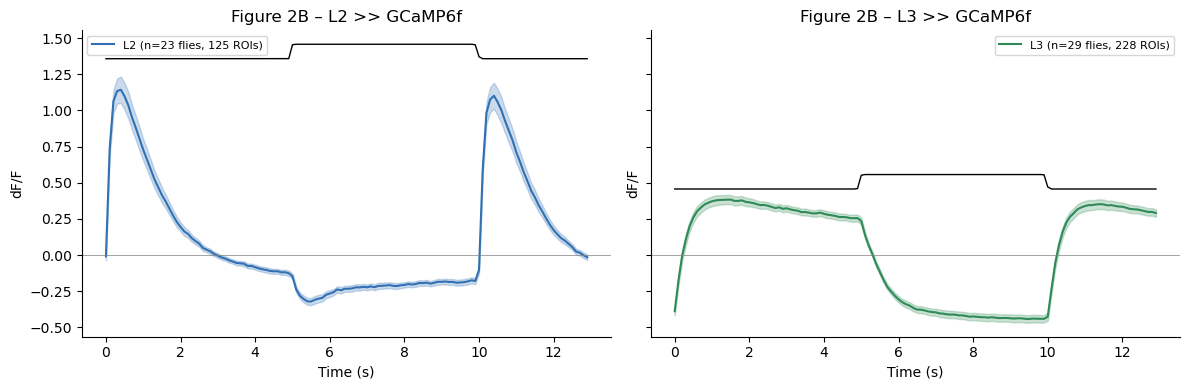

Done.


In [3]:
h5f = h5py.File(HDF5_PATH, "a")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
colors = {"L2": "#3070B3", "L3": "#2E8B57"}

for ax, cell_type in zip(axes, ["L2", "L3"]):
    data_dir = DATA_ROOT / "Figure2" / "Figure2B" / f"{cell_type}_pData"
    print(f"Loading {cell_type}...")
    roi_data = utils.load_figure_data(data_dir, summary, region="AT")
    agg = utils.aggregate_fff(roi_data)

    # Select negatively correlated ROIs
    neg, pos = utils.classify_rois_by_correlation(agg["rats"], agg["stims"])
    neg_rats = agg["rats"][neg]
    neg_ids = agg["flyID"][neg]
    neg_names = [agg["name"][i] for i in range(len(agg["name"])) if neg[i]]

    dur = neg_rats.shape[1]
    t = np.arange(dur) / utils.IRATE
    stim_trace = np.nanmean(agg["stims"][neg], axis=0)

    rats_c, fids_c, fly_m, gm, se = process_and_save(
        h5f, f"fig2b_{cell_type}", neg_rats, neg_ids, t, stim_trace,
        cell_type, "5s_full_field_flash", roi_names=neg_names)

    plot_err_patch(ax, t, gm, se, colors[cell_type],
                   label=f"{cell_type} (n={len(np.unique(fids_c))} flies, {len(rats_c)} ROIs)")
    # Stimulus overlay
    ax.plot(t, stim_trace * 0.1 + np.max(gm + se) * 1.1, "k", linewidth=1)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("dF/F")
    ax.set_title(f"Figure 2B – {cell_type} >> GCaMP6f")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print("Done.")

## Figure 2C – 60s Full-Field Flash

Sustained response to a 60-second ON stimulus in L3 neurons. Shows that L3 maintains a tonic response throughout the stimulus.

Loading L3 60s FFF...
  Saved fig2c_L3: 79 ROIs, 5 flies, shape=(79, 1201)


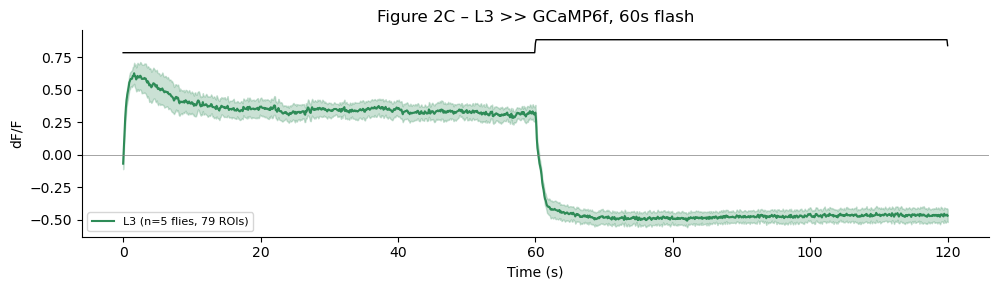

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))

data_dir = DATA_ROOT / "Figure2" / "Figure2C" / "L3_pData"
print("Loading L3 60s FFF...")
roi_data = utils.load_figure_data(data_dir, summary, region="AT")
agg = utils.aggregate_fff60s(roi_data)

neg, pos = utils.classify_rois_by_correlation(agg["rats"], agg["stims"])
neg_rats = agg["rats"][neg]
neg_ids = agg["flyID"][neg]
neg_names = [agg["name"][i] for i in range(len(agg["name"])) if neg[i]]

dur = neg_rats.shape[1]
t = np.arange(dur) / utils.IRATE
stim_trace = np.nanmean(agg["stims"][neg], axis=0)

rats_c, fids_c, fly_m, gm, se = process_and_save(
    h5f, "fig2c_L3", neg_rats, neg_ids, t, stim_trace,
    "L3", "60s_full_field_flash", roi_names=neg_names)

plot_err_patch(ax, t, gm, se, colors["L3"],
               label=f"L3 (n={len(np.unique(fids_c))} flies, {len(rats_c)} ROIs)")
ax.plot(t, stim_trace * 0.1 + np.max(gm + se) * 1.1, "k", linewidth=1)
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("dF/F")
ax.set_title("Figure 2C – L3 >> GCaMP6f, 60s flash")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Figure 2D-E – Contrast Steps from Grey Baseline

10 contrast epochs (5 OFF: grey→dark at 100-20%, 5 ON: bright→grey at 50-16%).
dF/F normalized to grey baseline. Shows contrast-response relationship.

Loading L2...
  Saved fig2dg_L2: 156 ROIs, 6 flies, shape=(156, 10, 250)


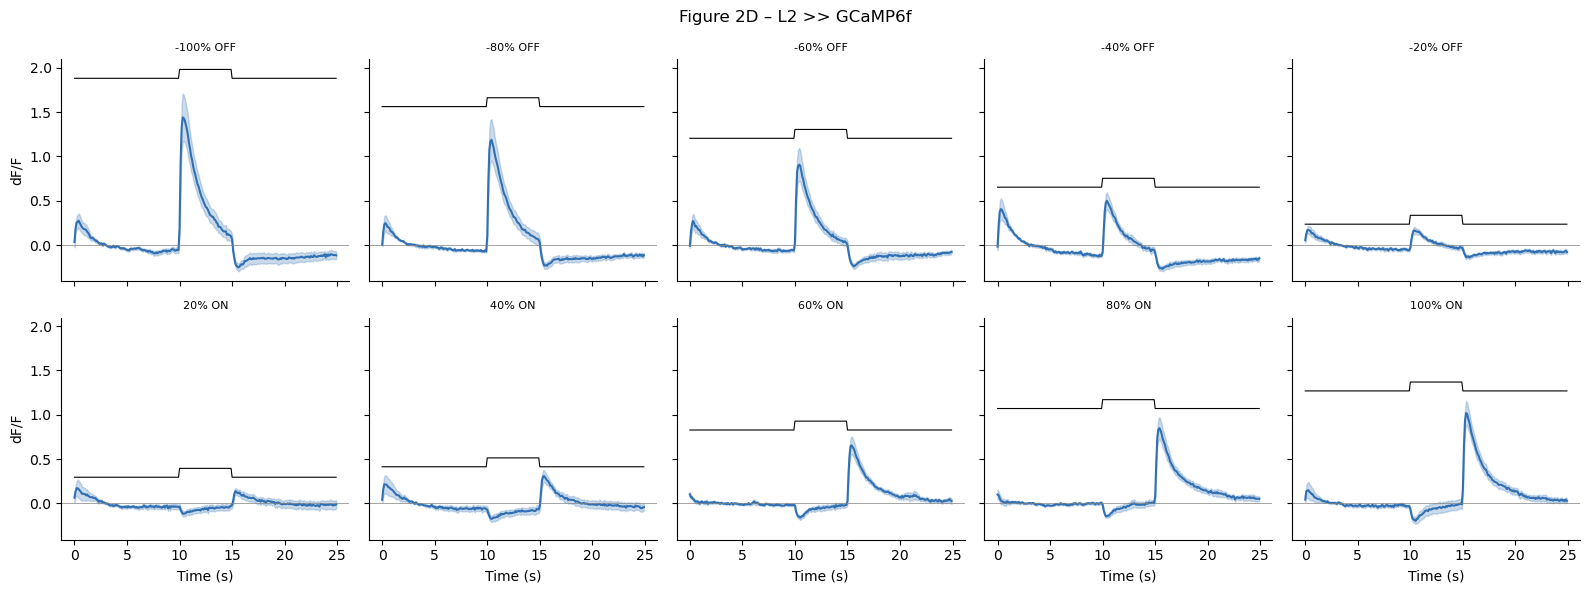

Loading L3...
  Saved fig2dg_L3: 93 ROIs, 5 flies, shape=(93, 10, 250)


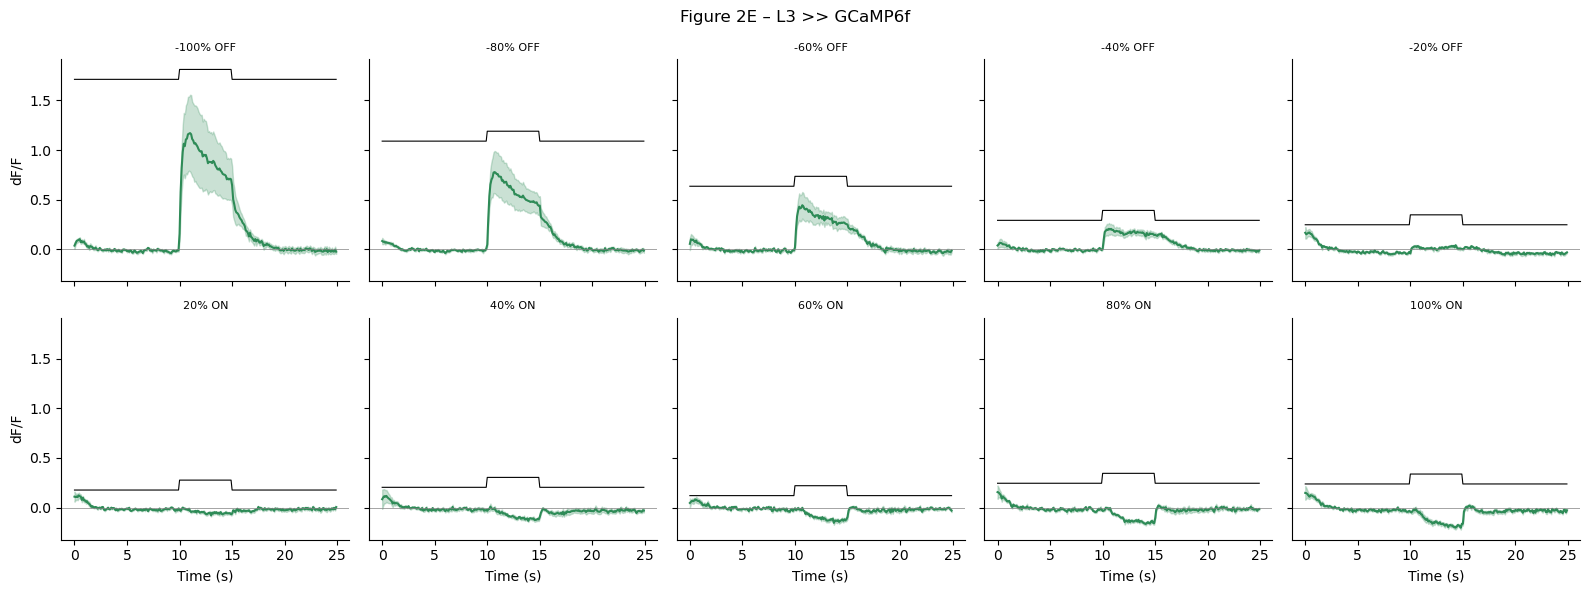

In [5]:
contrast_labels = [
    "-100% OFF", "-80% OFF", "-60% OFF", "-40% OFF", "-20% OFF",
    "20% ON", "40% ON", "60% ON", "80% ON", "100% ON",
]

for cell_type in ["L2", "L3"]:
    data_dir = DATA_ROOT / "Figure2" / "Figure2D_G" / f"{cell_type}_pData"
    print(f"Loading {cell_type}...")
    roi_data = utils.load_figure_data(data_dir, summary, region="AT")
    agg = utils.aggregate_standing_stripe(roi_data)

    n_epoch = agg["n_epoch"]
    full_dur = agg["rats"].shape[2]
    t = np.arange(full_dur) / utils.IRATE

    rats_c, fids_c, fly_m, gm, se = process_and_save(
        h5f, f"fig2dg_{cell_type}", agg["rats"], agg["flyID"], t,
        agg["stimstruct"], cell_type, "contrast_steps_grey_baseline",
        roi_names=agg["name"], epoch_labels=contrast_labels,
        extra_attrs={"contrast_values": [-100, -80, -60, -40, -20, 20, 40, 60, 80, 100]})

    # Plot all 10 epochs
    fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharey=True, sharex=True)
    for ep_idx, ax in enumerate(axes.flat):
        ep_mean = gm[ep_idx]
        ep_sem = se[ep_idx]
        plot_err_patch(ax, t, ep_mean, ep_sem, colors[cell_type])
        ax.plot(t, agg["stimstruct"] * 0.1 + np.max(ep_mean + ep_sem) * 1.1, "k", lw=0.8)
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.set_title(contrast_labels[ep_idx], fontsize=8)
        if ep_idx % 5 == 0:
            ax.set_ylabel("dF/F")
        if ep_idx >= 5:
            ax.set_xlabel("Time (s)")
    fig.suptitle(f"Figure 2{'D' if cell_type == 'L2' else 'E'} – {cell_type} >> GCaMP6f", fontsize=12)
    plt.tight_layout()
    plt.show()

## Figure 3A – Adapting Contrast Steps

OFF steps from different adapting backgrounds (A step → B step). The A step varies in luminance
(6 levels, 75%–21% of max), while the B step always has 25% Weber contrast relative to A.
Shows that L2 responses scale with contrast while L3 responses scale with luminance.

The physical stimulus has two distinct luminance steps within each 6s flash:
- A step (samples 150–179, 3s): first OFF step at epoch-specific luminance
- B step (samples 180–209, 3s): second OFF step at 75% of A luminance (25% Weber contrast)

Note: `fstimpos1` in the .mat data only records the A-step value for the entire epoch;
the A→B transition is not encoded in the stimulus metadata but is physically present.

7 epoch combinations extracted via cantor pairing; epoch 6 (fstimval=7) was excluded from the
paper analysis (no calibration). Each epoch = 36s (360 samples at 10 Hz).

Loading L2...


/home/bach/Documents/GitHub/KetkarSporar_2020_pydata/utils.py:783: RuntimeWarning: Mean of empty slice
  rats[ii, :, :] = np.nanmean(temp, axis=0)
/home/bach/Documents/GitHub/KetkarSporar_2020_pydata/utils.py:376: RuntimeWarning: Mean of empty slice
  fly_mean = np.nanmean(matrix[mask], axis=0)


  Saved fig3a_L2: 124 ROIs, 10 flies, shape=(124, 7, 360)
Loading L3...
  Saved fig3a_L3: 124 ROIs, 10 flies, shape=(124, 7, 360)


/tmp/ipykernel_249970/2598071584.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


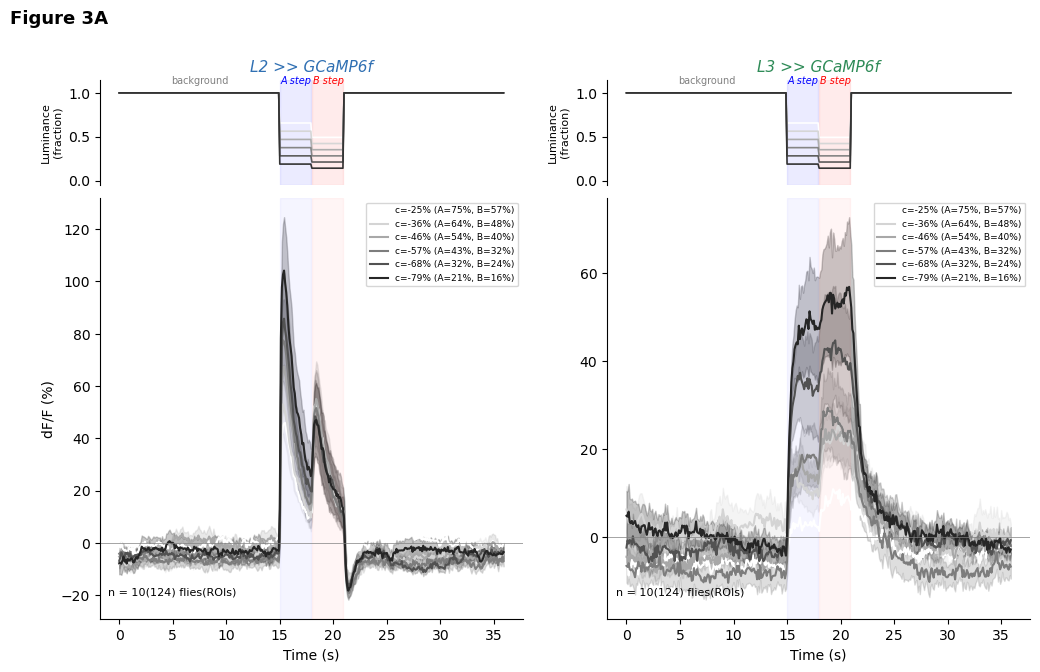

In [6]:
colors_3a = {"L2": "#3070B3", "L3": "#2E8B57"}
N_PLOT_EPOCHS = 6  # paper plots 6 epochs; epoch 6 excluded (no calibration)

fig, axes = plt.subplots(2, 2, figsize=(12, 7),
                         gridspec_kw={"height_ratios": [1, 4], "hspace": 0.05},
                         sharex=True)

for col, cell_type in enumerate(["L2", "L3"]):
    data_dir = DATA_ROOT / "Figure3" / "Figure3A_E" / f"{cell_type}_pData"
    print(f"Loading {cell_type}...")
    roi_data = utils.load_figure_data(data_dir, summary)
    agg = utils.aggregate_adapting_contrast(roi_data, off_stimulus=True)

    # Classify ROIs
    neg_mask = utils.classify_rois_adapting(agg["rats"], agg["flyID"])
    neg_rats = agg["rats"][neg_mask]
    neg_ids = agg["flyID"][neg_mask]
    neg_names = [agg["name"][i] for i in range(len(agg["name"])) if neg_mask[i]]

    total_len = neg_rats.shape[2]  # 360
    t = np.arange(total_len) / utils.IRATE

    # Save all 7 epochs to HDF5 with corrected labels and stimulus traces
    rats_c, fids_c, fly_m, gm, se = process_and_save(
        h5f, f"fig3a_{cell_type}", neg_rats, neg_ids, t,
        agg["stim_traces"],  # per-epoch stimulus traces (7, 360)
        cell_type, "adapting_contrast_OFF_OFF",
        roi_names=neg_names, epoch_labels=agg["epoch_labels"],
        extra_attrs={
            "a_luminance_pct": agg["a_luminance"],
            "b_luminance_pct": agg["b_luminance"],
            "a_contrast_pct": agg["a_contrast"],
        })

    # --- Stimulus schematic (top row) ---
    ax_stim = axes[0, col]
    # Each trace now shows the two-step structure: bg → A step → B step → bg
    for ep_idx in range(N_PLOT_EPOCHS):
        gray_level = 1.0 - ep_idx / (N_PLOT_EPOCHS - 1) * 0.8  # lighter to darker
        stim = agg["stim_traces"][ep_idx]
        ax_stim.plot(t, stim, color=str(gray_level), linewidth=1.2)
    ax_stim.set_ylabel("Luminance\n(fraction)", fontsize=8)
    ax_stim.set_ylim(-0.05, 1.15)
    ax_stim.set_yticks([0, 0.5, 1.0])
    ax_stim.spines["bottom"].set_visible(False)
    ax_stim.tick_params(bottom=False, labelbottom=False)
    # Mark A and B step regions separately
    ax_stim.axvspan(t[150], t[179], alpha=0.08, color="blue")
    ax_stim.axvspan(t[180], t[209], alpha=0.08, color="red")
    ax_stim.text(t[165], 1.1, "A step", ha="center", fontsize=7, fontstyle="italic", color="blue")
    ax_stim.text(t[195], 1.1, "B step", ha="center", fontsize=7, fontstyle="italic", color="red")
    ax_stim.text(t[75], 1.1, "background", ha="center", fontsize=7, color="gray")
    ax_stim.set_title(f"{cell_type} >> GCaMP6f", fontsize=11,
                      color=colors_3a[cell_type], fontstyle="italic")

    # --- Calcium traces (bottom row) ---
    ax_ca = axes[1, col]
    # Grayscale: darker trace = larger OFF step (matching paper)
    for ep_idx in range(N_PLOT_EPOCHS):
        gray_level = 1.0 - ep_idx / (N_PLOT_EPOCHS - 1) * 0.85
        color = str(gray_level)
        label = agg["epoch_labels"][ep_idx]
        plot_err_patch(ax_ca, t, gm[ep_idx] * 100, se[ep_idx] * 100,
                       color, label=label)

    # Shading for A and B step regions
    ax_ca.axvspan(t[150], t[179], alpha=0.04, color="blue")
    ax_ca.axvspan(t[180], t[209], alpha=0.04, color="red")

    ax_ca.axhline(0, color="gray", linewidth=0.5)
    ax_ca.set_xlabel("Time (s)")
    if col == 0:
        ax_ca.set_ylabel("dF/F (%)")
    ax_ca.legend(fontsize=6.5, loc="upper right", framealpha=0.8)
    ax_ca.text(0.02, 0.05,
               f"n = {len(np.unique(fids_c))}({len(rats_c)}) flies(ROIs)",
               transform=ax_ca.transAxes, fontsize=8, va="bottom")

fig.suptitle("Figure 3A", fontsize=13, x=0.05, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

### Figure 3A – HDF5 verification: A/B step stimulus structure

Reads the stored `stimulus_trace` back from HDF5 and overlays it with the grand-mean calcium
response. Verifies that the two-step structure (A step → B step) is correctly captured and
aligns with the second transient visible in the calcium data.

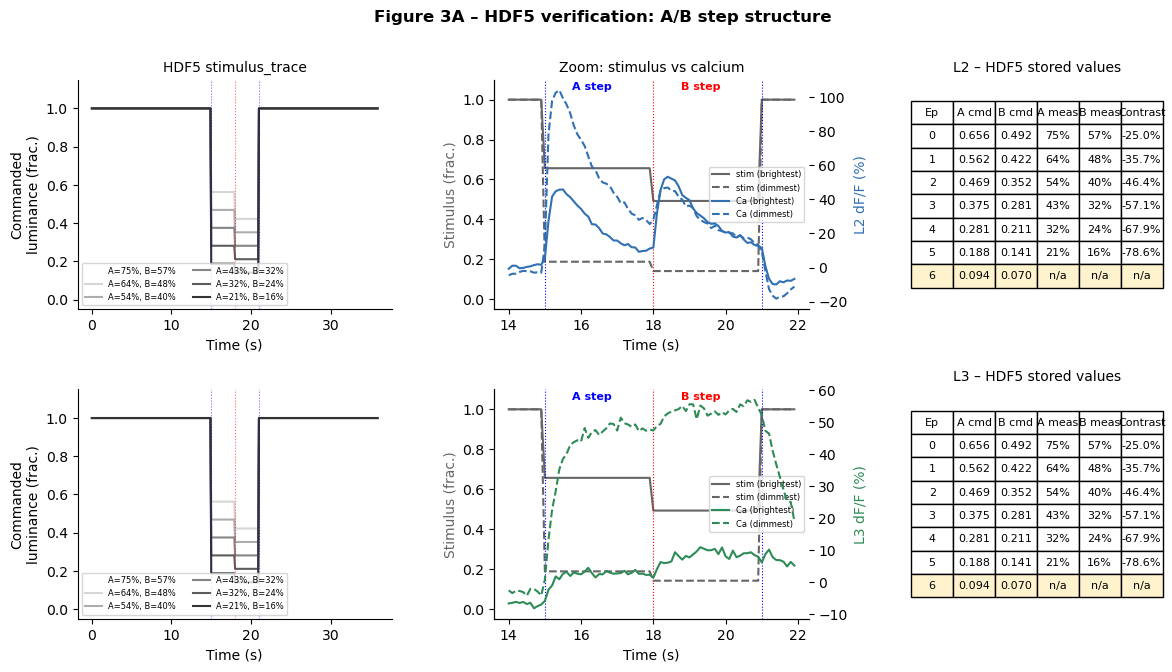

In [7]:
# Read Figure 3A data back from HDF5 and verify A/B step structure
with h5py.File(HDF5_PATH, "r") as f:
    fig = plt.figure(figsize=(14, 7))
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.8], hspace=0.35, wspace=0.35)

    for row, cell_type in enumerate(["L2", "L3"]):
        grp = f[f"fig3a_{cell_type}"]
        stim = grp["stimulus_trace"][:]        # (7, 360)
        gm = grp["per_fly/grand_mean"][:]      # (7, 360)
        sem = grp["per_fly/sem"][:]             # (7, 360)
        labels = [x.decode() if isinstance(x, bytes) else x
                  for x in grp["epoch_labels"][:]]
        t = grp["time"][:]
        a_lum = grp.attrs["a_luminance_pct"]
        b_lum = grp.attrs["b_luminance_pct"]

        ct_color = "#3070B3" if cell_type == "L2" else "#2E8B57"

        # --- Column 0: All 6 stimulus traces from HDF5 ---
        ax = fig.add_subplot(gs[row, 0])
        for ep in range(6):
            gl = 1.0 - ep / 5 * 0.8
            ax.plot(t, stim[ep], color=str(gl), linewidth=1.5,
                    label=f"A={a_lum[ep]}%, B={b_lum[ep]}%")
        ax.axvline(t[150], color="blue", ls=":", lw=0.8, alpha=0.6)
        ax.axvline(t[180], color="red", ls=":", lw=0.8, alpha=0.6)
        ax.axvline(t[210], color="blue", ls=":", lw=0.8, alpha=0.6)
        ax.set_ylabel("Commanded\nluminance (frac.)")
        ax.set_ylim(-0.05, 1.15)
        ax.set_xlabel("Time (s)")
        ax.legend(fontsize=6, loc="lower left", ncol=2)
        if row == 0:
            ax.set_title("HDF5 stimulus_trace", fontsize=10)

        # --- Column 1: Zoom into flash (samples 140–220) with dual y-axes ---
        ax = fig.add_subplot(gs[row, 1])
        t_zoom = t[140:220]
        # Stimulus on left axis
        for ep, ls, lbl in [(0, "-", "brightest"), (5, "--", "dimmest")]:
            ax.plot(t_zoom, stim[ep, 140:220], color="0.4", ls=ls, lw=1.5,
                    label=f"stim ({lbl})")
        ax.set_ylabel("Stimulus (frac.)", color="0.4")
        ax.set_ylim(-0.05, 1.1)
        ax.axvline(t[150], color="blue", ls=":", lw=0.8)
        ax.axvline(t[180], color="red", ls=":", lw=0.8)
        ax.axvline(t[210], color="blue", ls=":", lw=0.8)
        ax.text(t[163], 1.05, "A step", color="blue", fontsize=8,
                fontweight="bold", ha="center")
        ax.text(t[193], 1.05, "B step", color="red", fontsize=8,
                fontweight="bold", ha="center")
        # Calcium on right axis
        ax2 = ax.twinx()
        for ep, ls, lbl in [(0, "-", "brightest"), (5, "--", "dimmest")]:
            ax2.plot(t_zoom, gm[ep, 140:220] * 100, color=ct_color, ls=ls, lw=1.5,
                     label=f"Ca ({lbl})")
        ax2.set_ylabel(f"{cell_type} dF/F (%)", color=ct_color)
        # Combined legend
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=6, loc="center right")
        ax.set_xlabel("Time (s)")
        if row == 0:
            ax.set_title("Zoom: stimulus vs calcium", fontsize=10)

        # --- Column 2: A/B values table ---
        ax = fig.add_subplot(gs[row, 2])
        ax.axis("off")
        table_data = [["Ep", "A cmd", "B cmd", "A meas", "B meas", "Contrast"]]
        for ep in range(7):
            a_cmd = f"{stim[ep, 155]:.3f}"
            b_cmd = f"{stim[ep, 185]:.3f}"
            if ep < 6:
                a_m = f"{a_lum[ep]}%"
                b_m = f"{b_lum[ep]}%"
                c_val = f"{grp.attrs['a_contrast_pct'][ep]:.1f}%"
            else:
                a_m = "n/a"
                b_m = "n/a"
                c_val = "n/a"
            table_data.append([str(ep), a_cmd, b_cmd, a_m, b_m, c_val])
        tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                       loc="center", cellLoc="center")
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(8)
        tbl.scale(1.0, 1.4)
        # Highlight epoch 6 row (not in paper)
        for col_idx in range(6):
            tbl[7, col_idx].set_facecolor("#fff3cd")
        ax.set_title(f"{cell_type} – HDF5 stored values", fontsize=10)

    fig.suptitle("Figure 3A – HDF5 verification: A/B step structure",
                 fontsize=12, fontweight="bold")
    plt.show()

## Figure 3F – Random Luminance Steps (5 Levels)

Stimulus randomly switches between 5 luminance levels (100%OFF, 50%OFF, GREY, 50%ON, 100%ON), each held ~10s.
20 unique transition types are extracted. dF/F normalized to 100%ON baseline.
Shows responses grouped by transition type.

Loading L2...


/home/bach/Documents/GitHub/KetkarSporar_2020_pydata/utils.py:954: RuntimeWarning: Mean of empty slice
  rats[ii, :, :] = np.nanmean(temp, axis=0)


  Saved fig3f_L2: 305 ROIs, 35 flies, shape=(305, 20, 200)
Loading L3...
  Saved fig3f_L3: 352 ROIs, 40 flies, shape=(352, 20, 200)


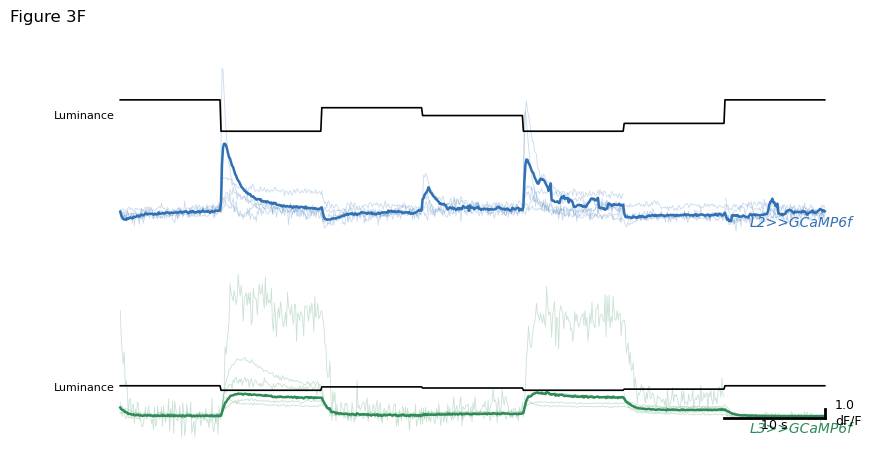

In [8]:
results_3f = {}

for cell_type in ["L2", "L3"]:
    data_dir = DATA_ROOT / "Figure3" / "Figure3F_H_I" / f"{cell_type}_pData"
    print(f"Loading {cell_type}...")
    roi_data = utils.load_figure_data(data_dir, summary)
    agg = utils.aggregate_05steps(roi_data)

    # Classify ROIs
    neg_mask, pos_mask = utils.classify_rois_05steps(agg["rats"])
    neg_rats = agg["rats"][neg_mask]
    neg_ids = agg["flyID"][neg_mask]
    neg_names = [agg["name"][i] for i in range(len(agg["name"])) if neg_mask[i]]

    n_time = neg_rats.shape[2]
    t = np.arange(n_time) / utils.IRATE

    # Stimulus pattern: first epoch then second epoch
    stim_pattern = np.zeros(n_time)
    stim_pattern[n_time // 2:] = 1.0

    rats_c, fids_c, fly_m, gm, se = process_and_save(
        h5f, f"fig3f_{cell_type}", neg_rats, neg_ids, t, stim_pattern,
        cell_type, "random_5level_luminance_steps",
        roi_names=neg_names, epoch_labels=agg["transition_labels"],
        extra_attrs={"epochlength_samples": agg["epochlength"]})

    results_3f[cell_type] = {
        "gm": gm, "se": se, "fly_m": fly_m,
        "labels": agg["transition_labels"],
        "epochlength": agg["epochlength"],
        "n_flies": len(np.unique(fids_c)),
        "n_rois": len(rats_c),
    }

# --- Paper-style Figure 3F: concatenated transitions ---
level_values = {
    "100%OFF": 0.0, "50%OFF": 0.25, "GREY": 0.5,
    "50%ON": 0.75, "100%ON": 1.0,
}

# Chain of transitions forming a continuous luminance sequence:
# 100%ON -> 100%OFF -> 50%ON -> GREY -> 100%OFF -> 50%OFF -> 100%ON
chain_indices = [16, 2, 14, 8, 0, 7]

colors_ct = {"L2": "#3070B3", "L3": "#2E8B57"}

fig, axes = plt.subplots(2, 1, figsize=(10, 5))
plt.subplots_adjust(hspace=0.15)

for ax, cell_type in zip(axes, ["L2", "L3"]):
    res = results_3f[cell_type]
    gm = res["gm"]
    fly_m = res["fly_m"]
    labels = res["labels"]
    epochlen = res["epochlength"]
    color = colors_ct[cell_type]

    # Concatenate grand mean: first transition in full, rest 2nd epoch only
    cat_parts = [gm[chain_indices[0]]]
    for idx in chain_indices[1:]:
        cat_parts.append(gm[idx, epochlen:])
    cat_mean = np.concatenate(cat_parts)
    total_t = np.arange(len(cat_mean)) / 10.0

    # Individual fly traces (thin lines)
    n_show = min(6, fly_m.shape[0])
    rng = np.random.default_rng(42)
    fly_subset = rng.choice(fly_m.shape[0], n_show, replace=False)
    for fi in fly_subset:
        parts = [fly_m[fi, chain_indices[0]]]
        for idx in chain_indices[1:]:
            parts.append(fly_m[fi, idx, epochlen:])
        cat_fly = np.concatenate(parts)
        ax.plot(total_t, cat_fly, color=color, alpha=0.25, linewidth=0.6)

    # Grand mean (thick line)
    ax.plot(total_t, cat_mean, color=color, linewidth=1.8)

    # Build luminance staircase
    level_seq = [labels[chain_indices[0]].split("->")[0]]
    for idx in chain_indices:
        level_seq.append(labels[idx].split("->")[1])

    stim_trace = np.zeros(len(cat_mean))
    pos = 0
    for lev in level_seq:
        seg_end = min(pos + epochlen, len(stim_trace))
        stim_trace[pos:seg_end] = level_values[lev]
        pos = seg_end

    # Draw staircase above the calcium traces
    y_max = np.nanmax(cat_mean) + 0.2
    stim_scaled = stim_trace * 0.5 + y_max
    ax.plot(total_t, stim_scaled, "k-", linewidth=1.2)
    ax.text(total_t[0] - 0.5, y_max + 0.25, "Luminance", fontsize=8,
            va="center", ha="right")

    # Cell type label (italic, in matching color)
    ax.text(0.99, 0.05, f"{cell_type}>>GCaMP6f", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=10, fontstyle="italic",
            color=color)

    # Remove axes for clean paper look
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_yticks([])
    ax.set_xticks([])

# Scale bars on bottom-right of bottom panel
ax = axes[1]
x_end = total_t[-1]
y_bot = np.nanmin(cat_mean) - 0.15

# 10 s horizontal bar
ax.plot([x_end - 10, x_end], [y_bot, y_bot], "k-", linewidth=2, clip_on=False)
ax.text(x_end - 5, y_bot - 0.08, "10 s", ha="center", va="top", fontsize=9)

# 1.0 dF/F vertical bar
ax.plot([x_end, x_end], [y_bot, y_bot + 1.0], "k-", linewidth=2, clip_on=False)
ax.text(x_end + 1, y_bot + 0.5, "1.0\ndF/F", ha="left", va="center", fontsize=9)

fig.suptitle("Figure 3F", fontsize=12, x=0.05, ha="left")
plt.show()

In [9]:
h5f.close()
print(f"\nAll data saved to {HDF5_PATH}")
print(f"File size: {HDF5_PATH.stat().st_size / 1e6:.1f} MB")

# List contents
with h5py.File(HDF5_PATH, "r") as f:
    print("\nHDF5 contents:")
    for key in f.keys():
        grp = f[key]
        attrs = dict(grp.attrs)
        print(f"  {key}: {attrs.get('cell_type', '?')}, "
              f"{attrs.get('stimulus_type', '?')}, "
              f"n_rois={attrs.get('n_rois', '?')}, "
              f"n_flies={attrs.get('n_flies', '?')}")


All data saved to processed_data.h5
File size: 37.8 MB

HDF5 contents:
  fig2b_L2: L2, 5s_full_field_flash, n_rois=125, n_flies=23
  fig2b_L3: L3, 5s_full_field_flash, n_rois=228, n_flies=29
  fig2c_L3: L3, 60s_full_field_flash, n_rois=79, n_flies=5
  fig2dg_L2: L2, contrast_steps_grey_baseline, n_rois=156, n_flies=6
  fig2dg_L3: L3, contrast_steps_grey_baseline, n_rois=93, n_flies=5
  fig3a_L2: L2, adapting_contrast_OFF_OFF, n_rois=124, n_flies=10
  fig3a_L3: L3, adapting_contrast_OFF_OFF, n_rois=124, n_flies=10
  fig3f_L2: L2, random_5level_luminance_steps, n_rois=305, n_flies=35
  fig3f_L3: L3, random_5level_luminance_steps, n_rois=352, n_flies=40
